In [113]:
# statistical tests using one time point, for correlation analysis 
#####  Load the correponding dataset 
#####  Perform GLM analysis for Gaussian distributions  
#####  Model diagnostic 
#####  Result presentation and Plotting   

In [114]:
import numpy as np
import pandas as pd

from scipy.stats import shapiro   # for normality test

from scipy.stats import f_oneway  # for Anova test (normal distribution)
from scipy.stats import kruskal   # for Kruskal-Wallis test (non-normal distribution)

import statsmodels.api as sm      # for Ancova, , non-formular form
import statsmodels.formula.api as smf # for ANCOVA test, formular form

from scipy.stats import rankdata  # for Rank-Based ANCOVA, for Non-Gaussian distributions

import seaborn as sns
import matplotlib.pyplot as plt

In [115]:
curRoot = 'C'  # 'C' or 'D'
# Load shape measures, SELECTED
curRegion = 'CSSyl' # !!! modify !!! CSSyl, CSpreCS
curSCA = 1         # !!! modify !!!
typeDist = 'max'

##############################################   Original   #############################################
# for CSpreCS analysis
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca1_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca2_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca3_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV_first_time_point\{curRegion}_ctl_sca7_time1_{typeDist}.csv'

#file_path_ctl_1_max = rf'D:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_max.csv'

# Time 1 and 2 separated, from combined set 
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time2_{typeDist}.csv'

# Time 1 and 2 combined, from combined set 
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\Combined_Select_CSV\{curRegion}_ctl_sca1_time1_and_2_{typeDist}.csv'

#Original, time1 only
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca1_{typeDist}.csv'

#Original REDO for verification
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\ORI\ORI_time1_ctl_sca1\{curRegion}\combined_time1_{typeDist}_ctl_sca1.csv'

# SCAs 2, 3, 7
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca2_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca3_{typeDist}.csv'
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\{curRegion}_atrilBioscaCermoi_combined_select_ctl_sca7_{typeDist}.csv'

###########################################    RELABEL     #############################################
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL\relabel_time1_ctl_sca{curSCA}\{curRegion}\combined_time1_{typeDist}_ctl_sca{curSCA}.csv'

###########################################   RELABEL, REDO    #############################################
# Not used by default in GLM, TIME 1 and 2
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_2_ctl_sca{curSCA}\{curRegion}\combined_time1_2_{typeDist}_ctl_sca{curSCA}.csv'
# Time 1 ONLY
curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_ctl_sca{curSCA}\{curRegion}\combined_time1_{typeDist}_ctl_sca{curSCA}.csv'
# Time 2 ONLY
#curPath = rf'{curRoot}:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time2_ctl_sca{curSCA}\{curRegion}\combined_time2_{typeDist}_ctl_sca{curSCA}.csv'


print(curPath)
combined = pd.read_csv(curPath)
print(len(combined))

### !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!  ###
####################################  only for time1 and 2 together  ####################################
#combined_time1 = combined[combined['Time_point']==1]
#combined_time2 = combined[combined['Time_point']!=1] # BIOSCA==2, CERMOI==3
#combined = combined_time2         ###########################    CHANGE    #############################
### !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!  ###

combined.index = combined['subjName']

# for specific analysis, remove NAs
combined_L = combined[combined.index.str.startswith('L')]
combined_R = combined[combined.index.str.startswith('flip')]
combined_only_SCA = combined[combined['SCA'] == curSCA]

combined_CAG = combined.dropna(subset=['CAG'])
combined_CAG_only_SCA = combined_CAG[combined_CAG['SCA'] == curSCA]

combined_CCFS = combined.dropna(subset=['CCFS'])
combined_CCFS_only_SCA = combined_CCFS[combined_CCFS['SCA'] == curSCA]

combined_INAS = combined.dropna(subset=['INAS'])
combined_INAS_only_SCA = combined_INAS[combined_INAS['SCA'] == curSCA]

C:\B_projWIP\proj_ataxia\RELABEL_REDO\RELABEL_REDO_time1_ctl_sca1\CSSyl\combined_time1_max_ctl_sca1.csv
86


In [253]:
# Centering values
def centering_values(df):
    df.loc[:,'CAG_centered'] = df['CAG'] - df['CAG'].mean()
    df.loc[:,'SARA_centered'] = df['SARA'] - df['SARA'].mean()
    df.loc[:,'CCFS_centered'] = df['CCFS'] - df['CCFS'].mean()
    df.loc[:,'INAS_centered'] = df['INAS'] - df['INAS'].mean()    
    df.loc[:,'Age_onset_centered'] = df['Age_onset'] - df['Age_onset'].mean()
    df.loc[:,'Age_centered'] = df['Age'] - df['Age'].mean()
    df.loc[:,'iso1_centered'] = df['iso1'] - df['iso1'].mean()   
    df.loc[:,'iso2_centered'] = df['iso2'] - df['iso2'].mean()       
    df.loc[:,'iso3_centered'] = df['iso3'] - df['iso3'].mean()   
    df.loc[:,'UMAP1_U1_centered'] = df['UMAP1_U1'] - df['UMAP1_U1'].mean()   
    df.loc[:,'UMAP1_U2_centered'] = df['UMAP1_U2'] - df['UMAP1_U2'].mean() 
    df.loc[:,'UMAP1_U3_centered'] = df['UMAP1_U3'] - df['UMAP1_U3'].mean() 
    df.loc[:,'UMAP2_U3_centered'] = df['UMAP2_U3'] - df['UMAP2_U3'].mean() 
    df.loc[:,'UMAP1_U4_centered'] = df['UMAP1_U4'] - df['UMAP1_U4'].mean() 
    df.loc[:,'UMAP2_U4_centered'] = df['UMAP2_U4'] - df['UMAP2_U4'].mean() 
    df.loc[:,'iso1_asy_centered'] = df['iso1_asy'] - df['iso1_asy'].mean()   
    df.loc[:,'iso2_asy_centered'] = df['iso2_asy'] - df['iso2_asy'].mean()       
    df.loc[:,'iso3_asy_centered'] = df['iso3_asy'] - df['iso3_asy'].mean()      
    return df

combined_CAG_only_SCA_centered =  centering_values(combined_CAG_only_SCA)


In [279]:
combined_CAG_only_SCA_centered_L = combined_CAG_only_SCA_centered[combined_CAG_only_SCA_centered.index.str.startswith('L')]
combined_CAG_only_SCA_centered_R = combined_CAG_only_SCA_centered[combined_CAG_only_SCA_centered.index.str.startswith('flip')]

In [117]:
##############################  Verifications  ###############################

In [118]:
combined.columns

Index(['subjName', 'label', 'surface_talairach', 'surface_native',
       'maxdepth_talairach', 'maxdepth_native', 'meandepth_talairach',
       'meandepth_native', 'hull_junction_length_talairach',
       'hull_junction_length_native', 'GM_thickness', 'opening',
       'Randomization', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS',
       'Time_point', 'CodeICM', 'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2',
       'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'Age_onset',
       'Group_ctl_pre_pat', 'Handedness', 'CCFS', 'Disease_duration',
       'allele1', 'allele2', 'side', 'SCA_side', 'dominantSide',
       'SCA_dominantSide', 'iso1_asy', 'iso2_asy', 'iso3_asy', 'UMAP1_U1_asy',
       'UMAP1_U2_asy', 'UMAP1_U3_asy', 'UMAP2_U3_asy', 'UMAP1_U4_asy',
       'UMAP2_U4_asy', 'surface_talairach_asy', 'surface_native_asy',
       'maxdepth_talairach_asy', 'maxdepth_native_asy',
       'meandepth_talairach_asy', 'meandepth_native_asy',
       'hull_junction_length_talairach_asy', 'hull_

In [119]:
print(len(combined_CAG))
print(len(combined_only_SCA))
print(len(combined_CAG_only_SCA))
print(combined_CAG.columns)

44
32
32
Index(['subjName', 'label', 'surface_talairach', 'surface_native',
       'maxdepth_talairach', 'maxdepth_native', 'meandepth_talairach',
       'meandepth_native', 'hull_junction_length_talairach',
       'hull_junction_length_native', 'GM_thickness', 'opening',
       'Randomization', 'SCA', 'CAG', 'Sex', 'Age', 'SARA', 'INAS',
       'Time_point', 'CodeICM', 'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2',
       'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4', 'Age_onset',
       'Group_ctl_pre_pat', 'Handedness', 'CCFS', 'Disease_duration',
       'allele1', 'allele2', 'side', 'SCA_side', 'dominantSide',
       'SCA_dominantSide', 'iso1_asy', 'iso2_asy', 'iso3_asy', 'UMAP1_U1_asy',
       'UMAP1_U2_asy', 'UMAP1_U3_asy', 'UMAP2_U3_asy', 'UMAP1_U4_asy',
       'UMAP2_U4_asy', 'surface_talairach_asy', 'surface_native_asy',
       'maxdepth_talairach_asy', 'maxdepth_native_asy',
       'meandepth_talairach_asy', 'meandepth_native_asy',
       'hull_junction_length_talairach_asy

In [120]:
########################################  Stats  #############################################

In [291]:
##############################  LMM, Result Verification   ############################## 
##  Since the hemisphere is a repeated measure even using one time point

# Create the new 'subject' column by removing prefixes
combined_CAG_only_SCA_centered['subject'] = (
    combined_CAG_only_SCA_centered['subjName']
    .str.replace(r'^L', '', regex=True)          # Remove 'L' if it starts the string
    .str.replace(r'^flip[-_]?R', '', regex=True) # Remove 'flip-R' or 'flip_R' if it starts the string
)


measure = 'iso1_centered'
x_var = 'SARA_centered * CAG_centered + Age_centered + C(side)'  # Fixed effects

random_effect = 'subject'  # Subject identifier column

formula = rf'{measure} ~ {x_var}'  # Fixed effects formula

# Fit a linear mixed-effects model with subject as a random intercept
model = smf.mixedlm(formula, data=combined_CAG_only_SCA_centered, groups=combined_CAG_only_SCA_centered[random_effect])
result = model.fit()

# Output
print(rf'LMM results for ###################    {measure}    ###################:')
print(result.summary())
print("\n" + "="*80 + "\n")


LMM results for ###################    iso1_centered    ###################:
                Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    iso1_centered
No. Observations:     32         Method:                REML         
No. Groups:           16         Scale:                 7.0393       
Min. group size:      2          Log-Likelihood:        -84.0807     
Max. group size:      2          Converged:             Yes          
Mean group size:      2.0                                            
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   0.744    0.800  0.931 0.352 -0.823  2.312
C(side)[T.R]               -1.480    0.938 -1.578 0.115 -3.319  0.359
SARA_centered              -0.400    0.156 -2.564 0.010 -0.706 -0.094
CAG_centered                0

C:\Users\joyca\AppData\Local\Temp\ipykernel_22516\3684307870.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_CAG_only_SCA_centered['subject'] = (


In [287]:
#################  use GLM to model the correlation, instead of partial correlation as above  ###################
#####  with Age_onset, collinearity problem !!! #####
#model = smf.ols(formula='iso1_centered ~ CAG_centered + Age_onset + C(side)', data=combined_CAG_only_SCA_centered).fit()
#model = smf.ols(formula='iso1_centered ~ SARA_centered + CAG_centered * Age_onset + C(side)', data=combined_CAG_only_SCA_centered).fit()
#model = smf.ols(formula='iso1_centered ~ SARA_centered + CAG_centered + Age_onset + C(side)', data=combined_CAG_only_SCA_centered).fit()
#model = smf.ols(formula='iso1_centered ~ SARA_centered + CAG_centered + Age_onset + C(side) + C(Sex)', data=combined_CAG_only_SCA_centered).fit()

#####  with Age, no collinearity problem  #####
#model = smf.ols(formula='iso1_centered ~ SARA_centered + CAG_centered + Age_centered + C(side) + C(Sex)', data=combined_CAG_only_SCA_centered).fit()
#model = smf.ols(formula='iso1_centered ~ SARA_centered + CAG_centered + Age_centered + C(side)', data=combined_CAG_only_SCA_centered).fit()

#####  check interaction  #####
#model = smf.ols(formula='iso1_centered ~ SARA_centered * CAG_centered + Age_centered + C(side) + C(Sex)', data=combined_CAG_only_SCA_centered).fit()
model = smf.ols(formula='iso1_centered ~ SARA_centered * CAG_centered + Age_centered + C(side)', data=combined_CAG_only_SCA_centered).fit()

#####  by hemisphere  ####
#model = smf.ols(formula='iso1_centered ~ SARA_centered + CAG_centered + Age_centered + C(Sex)', data=combined_CAG_only_SCA_centered_L).fit()
#model = smf.ols(formula='iso1_centered ~ SARA_centered * CAG_centered + Age_centered + C(Sex)', data=combined_CAG_only_SCA_centered_L).fit()
#model = smf.ols(formula='iso1_centered ~ SARA_centered + CAG_centered + Age_centered + C(Sex)', data=combined_CAG_only_SCA_centered_R).fit()

# Print the summary
print(model.summary())


#########################  display with more precision  ########################
# Extract coefficients table as DataFrame
summary_df = model.summary2().tables[1]  # table 1 = coefficient table

# Display full precision
pd.options.display.float_format = '{:.10f}'.format
print(summary_df)


                            OLS Regression Results                            
Dep. Variable:          iso1_centered   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.248
Method:                 Least Squares   F-statistic:                     3.042
Date:                Fri, 25 Jul 2025   Prob (F-statistic):             0.0271
Time:                        16:34:38   Log-Likelihood:                -78.500
No. Observations:                  32   AIC:                             169.0
Df Residuals:                      26   BIC:                             177.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [203]:
#############################  Calculating VIF  ##############################

from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices

# Step 1: Define your formula
formula = 'iso1 ~ SARA + CAG + Age_onset + C(side)'
#formula = 'iso1_centered ~ SARA_centered + CAG_centered + Age_centered + C(side) + C(Sex)'
#formula = 'iso1_centered ~ SARA_centered + CAG_centered + Age_centered + C(side)'

# Step 2: Create design matrices
y, X = dmatrices(formula, data=combined_CAG_only_SCA, return_type='dataframe')

# Step 3: Compute VIF for each explanatory variable
vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Step 4: Display VIF table
print(vif_df)


       Variable            VIF
0     Intercept 910.0978127335
1  C(side)[T.R]   1.0000000000
2          SARA   1.1164109084
3           CAG   7.9147018970
4     Age_onset   8.0777493524


In [123]:
####################################  Model Diagnostics, tests  ######################################
model = smf.ols(formula='iso1_centered ~ SARA_centered * CAG_centered + Age_centered + C(side) + C(Sex)', data=combined_CAG_only_SCA).fit()
residuals = model.resid

##################  Normality test of the residual  ####################
# shapiro: if p > 0.05, not normal
from scipy.stats import shapiro
shapiro_stat, p_value = shapiro(model.resid)
print(f"Shapiro-Wilk p-value: {p_value:.4f}")

##################  Normality test of the residual  ####################
# Kolmogorov-Smirnov: if p > 0.05, not normal
# The K-S test is sensitive to outliers and assumes known parameters (mean and std). 
# When applied to estimated residuals, it can be conservative or misleading.
# It’s generally less powerful than the Shapiro-Wilk test for normality.
from scipy.stats import kstest, norm
ks_stat, ks_p = kstest(residuals, 'norm', args=(residuals.mean(), residuals.std()))
print(f"Kolmogorov-Smirnov test p-value: {ks_p:.4f}")

#########################	 Heteroscedasticity Tests  ##########################
## If you’re concerned about non-constant variance: Breusch-Pagan test (for linear models):
## If > 0.05, no evidence of heteoscedasticity
from statsmodels.stats.diagnostic import het_breuschpagan
_, pval, _, _ = het_breuschpagan(residuals, model.model.exog)
print("Breusch-Pagan p-value:", pval)


Shapiro-Wilk p-value: 0.5327
Kolmogorov-Smirnov test p-value: 0.7524
Breusch-Pagan p-value: 0.3571072976823087


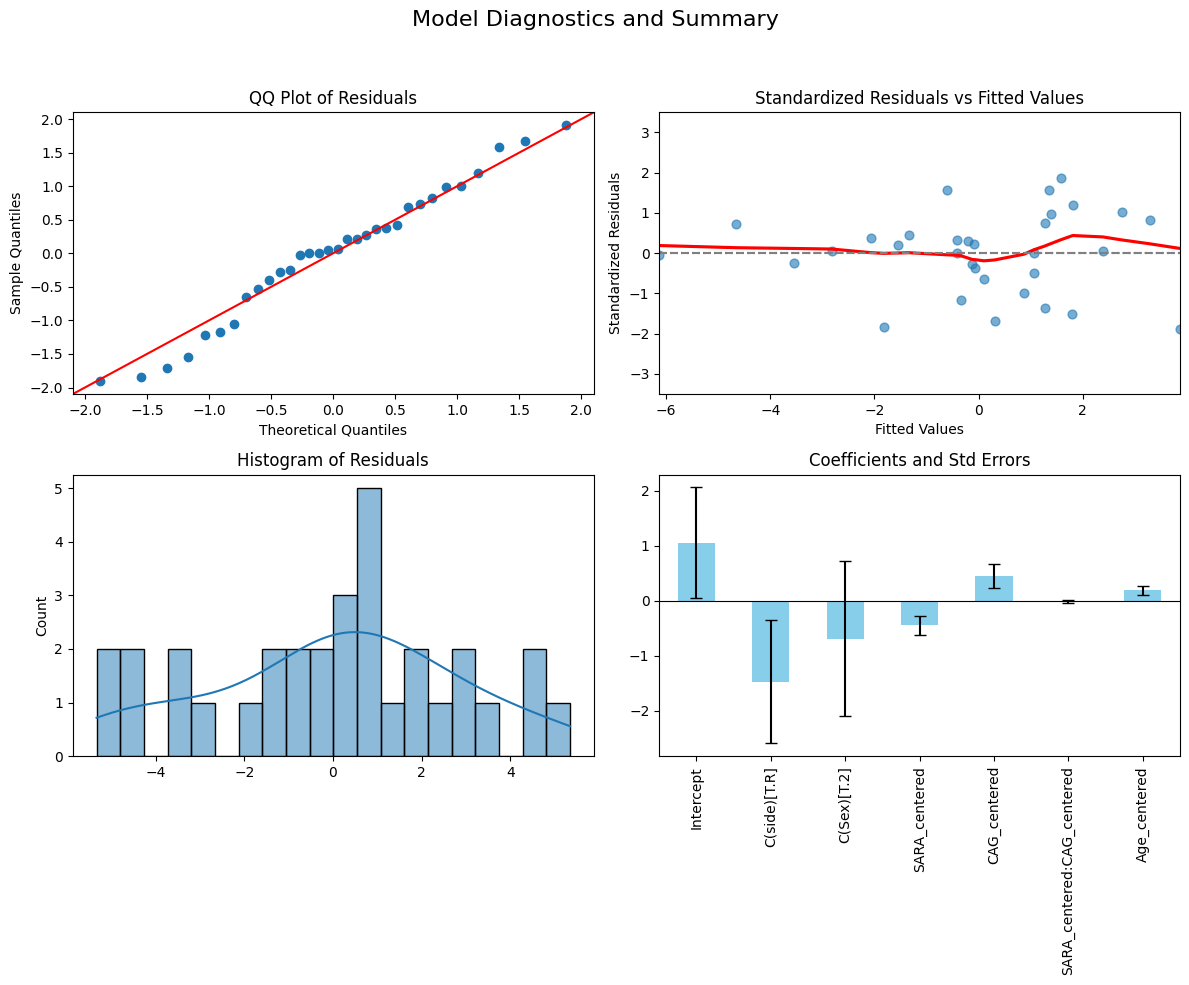

In [239]:
####################################  Model Diagnostics, plots  ######################################
# Fit your LMM
formula = 'iso1_centered ~ SARA_centered * CAG_centered + Age_centered + C(side) + C(Sex)'
model = smf.ols(formula, data=combined_CAG_only_SCA).fit()            # Fit the model  

# --- Print summary statistics ---
#print(model.summary())

# --- Set up multi-plot display ---
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Model Diagnostics and Summary', fontsize=16)

# --- QQ Plot ---
sm.qqplot(model.resid, line='45', ax=axs[0, 0],fit=True)
axs[0, 0].set_title('QQ Plot of Residuals')

# --- Residuals vs. Fitted ---
"""
############################  non-standardized residual  ###########################
sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True, ax=axs[0, 1],
              line_kws={'color': 'red'})
axs[0, 1].set_title('Residuals vs Fitted')
axs[0, 1].set_xlabel('Fitted values')
axs[0, 1].set_ylabel('Residuals')
"""
############################  standardized residual  ###########################
# normalized residuals, accounting for variance in the model.
# Values > ±2 or ±3 can indicate outliers.
# More interpretable than raw residuals when plotting diagnostics.
influence = model.get_influence()
standardized_resid = influence.resid_studentized_internal # Get studentized (standardized) residuals

sns.residplot(
    x=model.fittedvalues,
    y=standardized_resid,
    lowess=True,
    scatter_kws={'alpha': 0.6, 's': 40},
    line_kws={'color': 'red'},
    ax=axs[0, 1]
)

axs[0, 1].axhline(0, color='gray', linestyle='--')
axs[0, 1].set_title("Standardized Residuals vs Fitted Values")
axs[0, 1].set_xlabel("Fitted Values")
axs[0, 1].set_ylabel("Standardized Residuals")
axs[0, 1].set_ylim(-3.5, 3.5)  # Optional, but helps visually


# --- Histogram of Residuals ---
sns.histplot(model.resid, bins=20, kde=True, ax=axs[1, 0])
axs[1, 0].set_title('Histogram of Residuals')

# --- Coefficients bar plot ---
coefs = model.params
errors = model.bse
coefs.plot(kind='bar', yerr=errors, ax=axs[1, 1], color='skyblue', capsize=4)
axs[1, 1].set_title('Coefficients and Std Errors')
axs[1, 1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\GLM_ctl_Sca1\correlation_diag.png')

plt.show()


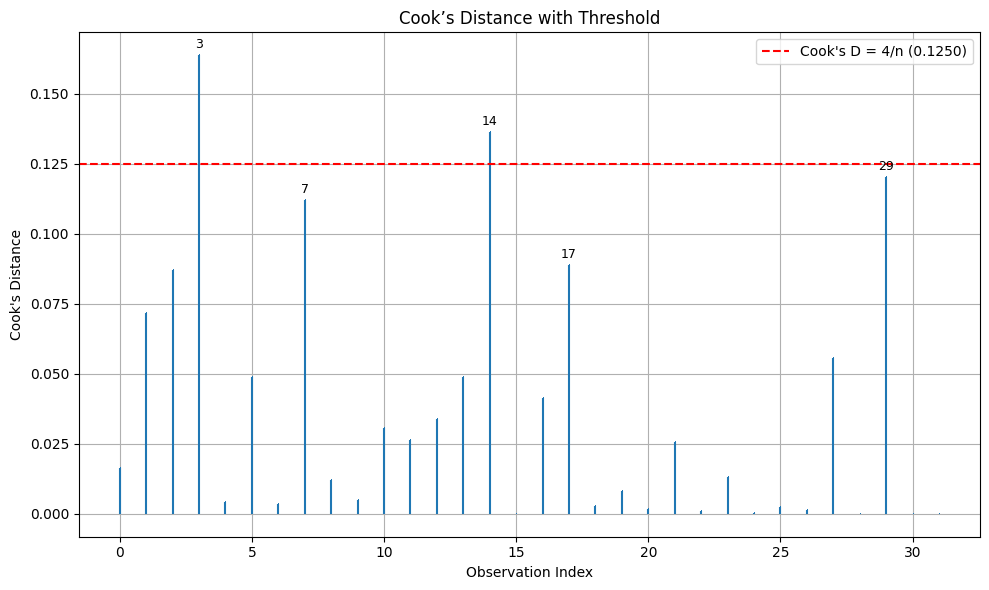


Top influential observations (by Cook's distance):
 obs_index          subjName      cooks_d
         3      L001039CD_E1 0.1637194872
        14      L001095MP_E1 0.1363451813
        29 flip-R001094GE_E1 0.1203897581
         7      L001077MR_E1 0.1120832345
        17 flip-R001029DJ_E1 0.0888891731


In [243]:
########################  outlier diagnosis, Cook's distance Plot  #########################

# 1. Compute Cook's distance
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

# 2. Create DataFrame with observation index and subject info
df_cooks = pd.DataFrame({
    "obs_index": range(len(cooks_d)),
    "subjName": combined_CAG_only_SCA["subjName"].values,  # assuming df has this column
    "cooks_d": cooks_d
})

# 3. Sort to get top N influential points
top_n = 5
top_cooks = df_cooks.sort_values("cooks_d", ascending=False).head(top_n)

# 4. Plot Cook’s Distance with threshold
plt.figure(figsize=(10, 6))
plt.stem(df_cooks["obs_index"], df_cooks["cooks_d"], markerfmt=",", basefmt=" ")

# Add Cook's D threshold line
n = len(combined_CAG_only_SCA)  # number of observations
threshold = 4 / n
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Cook\'s D = 4/n ({threshold:.4f})')

# Annotate the top influential observations
for _, row in top_cooks.iterrows():
    plt.annotate(row["obs_index"],
                 (row["obs_index"], row["cooks_d"]),
                 textcoords="offset points", xytext=(0, 5), ha='center', fontsize=9)

plt.title("Cook’s Distance with Threshold")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.legend()
plt.grid(True)
plt.tight_layout()

#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\GLM_ctl_Sca1\correlation_diag_Cook.png')
plt.show()

# 5. Print mapping of observation index to subject name
print("\nTop influential observations (by Cook's distance):")
print(top_cooks[["obs_index", "subjName", "cooks_d"]].to_string(index=False))

#plt.show()


In [126]:
#########################  Data Inspection and Plotting  ########################

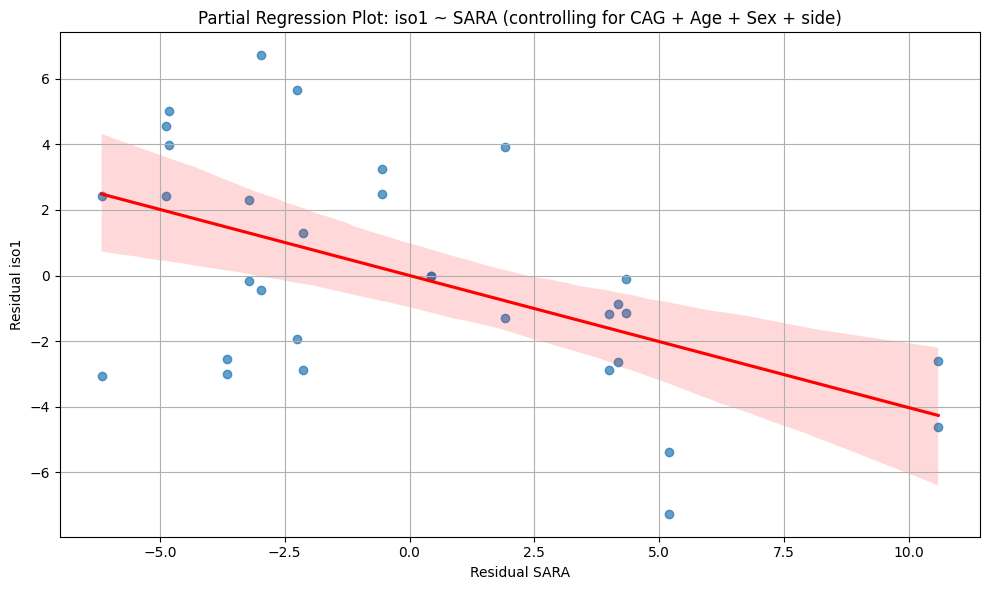

In [251]:
###############   Plotting taking into account the residuals   ###############
# Use linear regression with Pearson's coef between residuals

curMeasure = 'iso1'

#curCorVal = 'CAG'
#partialCorCol = ['SARA','Age', 'Sex','side']            
#partialCorParam = 'SARA + Age + Sex + side'

curCorVal = 'SARA'
partialCorCol = ['CAG','Age', 'Sex','side']            
partialCorParam = 'CAG + Age + Sex + side'

#curCorVal = 'Age'
#partialCorCol = ['CAG','SARA', 'Sex','side']            
#partialCorParam = 'CAG + SARA + Sex + side'

# Define mapping of curCorVal to DataFrame
data_map = {
    'INAS': combined_INAS_only_SCA,
    'CAG': combined_CAG_only_SCA,
    'CCFS': combined_CCFS_only_SCA,
    'SARA': combined_only_SCA,
    'Age': combined_only_SCA    
}
curData = data_map.get(curCorVal, None)
# Optional: Raise an error or provide a message if curCorVal is invalid
if curData is None:
    print(f"Warning: No data found for curCorVal = '{curCorVal}'")
    
# Prepare the data
df = curData[[curMeasure, curCorVal] + partialCorCol] # Ensure required columns are present

################  negate the slope, optional  ################
# for matching visual direction with another figure if needed
#df[curCorVal] = -df[curCorVal]
##############################################################

# Fit the OLS model using smf.ols with missing='drop'
model = smf.ols(formula=curMeasure+' ~ '+ curCorVal +' + ' + partialCorParam, data=df, missing='drop').fit()

# Partial regression: calculate residuals
residual_x = smf.ols(formula=curMeasure+' ~ '+partialCorParam, data=df, missing='drop').fit().resid
# Residual of curCorVal regressed
residual_y = smf.ols(formula=curCorVal+' ~ '+partialCorParam, data=df, missing='drop').fit().resid
raw_y = df[curCorVal]

# Align indices to ensure lengths match
residual_x, raw_y = residual_x.align(raw_y, join='inner')

## Plot the residuals
plt.figure(figsize=(10, 6))

#sns.regplot(x=residual_x, y=raw_y, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'}) # plot y raw CAG

# if emphasize effect of CAG on shape
sns.regplot(x=residual_y, y=residual_x, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'}) 
plt.ylabel('Residual '+curMeasure)      # plot x_CAG, y_shape
plt.xlabel('Residual '+curCorVal) 

# if emphasize effect of shape on CAG
#sns.regplot(x=residual_x, y=residual_y, scatter_kws={'alpha': 0.7}, line_kws={'color': 'red'}) 
#plt.ylabel('Residual '+curCorVal)      # plot x_shape, y_CAG
#plt.xlabel('Residual '+curMeasure) 

plt.title('Partial Regression Plot: '+curMeasure+' ~ '+curCorVal+' (controlling for '+partialCorParam+')')

plt.grid()
plt.tight_layout()
#############################################################################################
#plt.savefig(r'C:\B_projWIP\proj_ataxia\plots_CSSyl_RELABEL_REDO\GLM_ctl_Sca1\correlation_iso1_SARA.png')
plt.show()

C:\Users\joyca\AppData\Local\Temp\ipykernel_22516\4133423010.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_CAG_only_SCA['Sex_Side'] = combined_CAG_only_SCA['Sex'].astype(str) + ' | ' + combined_CAG_only_SCA['SCA_side'].astype(str)


Text(0, 0.5, 'Density')

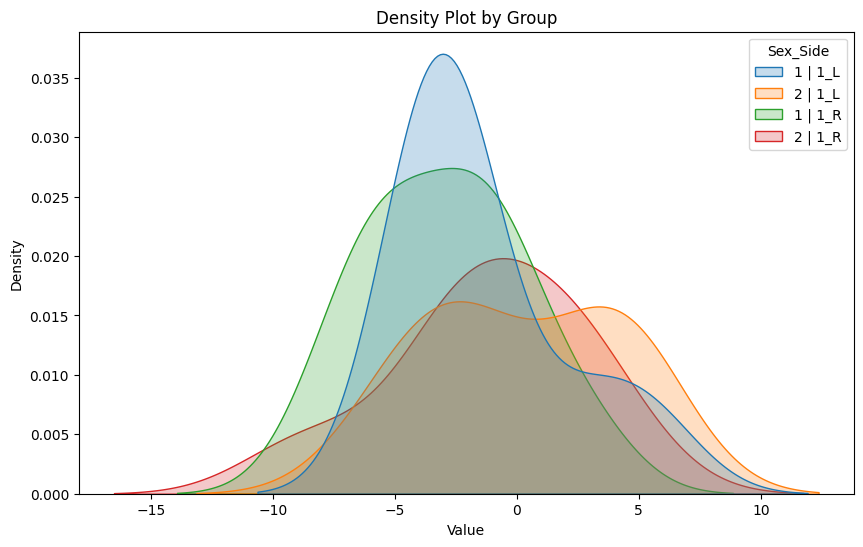

In [128]:
#################  density plot multiple groups  ##################
combined_CAG_only_SCA['Sex_Side'] = combined_CAG_only_SCA['Sex'].astype(str) + ' | ' + combined_CAG_only_SCA['SCA_side'].astype(str)

plt.figure(figsize=(10, 6))
#sns.kdeplot(data=combined_CAG_only_SCA, x='iso1', hue='SCA_side', fill=True) # default colors
sns.kdeplot(data=combined_CAG_only_SCA, x='iso1', hue='Sex_Side', fill=True) # default colors

# Customize the plot
plt.title('Density Plot by Group')
plt.xlabel('Value')
plt.ylabel('Density')

#plt.savefig(r'D:\B_projWIP\proj_ataxia\plots_dec_2024\density_combined_ctl_SCA1_time2_inBoth_max_byHemisphere.png')

In [191]:
##############################  FOR RECORD ONLY  ###############################

########  Perform ANCOVA and GLM analysis, Gaussian distribution  ########
########  Perform ranked ANCOVA, non-Gaussian distribution  ########
########   Adding covariates, two or multiple groups   ########

def ancovaGLMTests(df,measures,x_var):   # df, measures are the dependant variables, x_var is the independant variables
    df.loc[:, 'SCA'] = df['SCA'].astype('category')       # Ensure 'SCA' is a categorical variable    
    results_dict = {}                                     # Initialize a dictionary to store results
   
    ##covariates = 'Age + C(Sex) + C(side)'                
    ##covariates = 'Age + C(Sex) + C(side) + C(CodeICM)'  # if NOT from the same centre   
    #covariates = 'Age + C(Sex) + C(side) + Age_onset'              # if ONLY patients
    #covariatesRanked = ['Age','Sex','side','Age_onset']         # if ONLY patients
    covariates = 'Age + C(side) + C(Sex)'              # if ONLY patients
    covariatesRanked = ['Age','side','C(Sex)']         # if ONLY patients
    #covariates = 'Age + C(side)'              
    #covariatesRanked = ['Age','side']            
    
    for measure in measures:
        formula = rf'{measure} ~ {x_var} + {covariates}'   # Define the model formula dynamically       
        model = smf.ols(formula, data=df).fit()            # Fit the model        
        print(rf'ANCOVA results for ###################    {measure}    ###################:')
        print(model.summary())
        print("\n" + "="*80 + "\n")  # Divider between each measure's output
        anova_table = sm.stats.anova_lm(model, typ=2) 
        print(anova_table)
        
        ###################      Format p-value in scientific notation     ###################
        summary_table = pd.DataFrame({         
            'Coefficient': model.params,
            'Standard Error': model.bse,
            't-Value': model.tvalues,
            'P-Value': model.pvalues.apply(lambda x: f"{x:.2e}")  # Format p-values in scientific notation
        })        
        #print("Custom ANCOVA Results:")     # Display formatted results, ONLY if scientific notation needed
        #print(summary_table)

        ########################################     GLM     #######################################
        print("============================   GLM " + measure + "  ============================")
        glm_model = smf.glm(formula=formula, data=df).fit()
        print(f"GLM results for {measure}:\n")
        print(glm_model.summary())

        #######################    Ranked ANCOVA for non_Gaussian data    ########################
        covariatesRanked = [cov.strip() for cov in covariatesRanked if cov.strip()]

        df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable       
        # Formula: Outcome ~ Group + Covariate  
        formula = rf"Ranked_Outcome ~ {x_var} + {' + '.join(covariatesRanked)}"    # Step 2: Perform ANCOVA on Ranked Data
        model = smf.ols(formula, data=df).fit()

        # Display the summary
        print("========================   Rank-Based ANCOVA: " + measure + "==========================" )
        print(model.summary())

measures_complete = [
    'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4',
    'surface_talairach','surface_native','maxdepth_talairach','maxdepth_native','meandepth_talairach',
    'meandepth_native','hull_junction_length_talairach','hull_junction_length_native','GM_thickness','opening',
    'iso1_asy','iso2_asy','iso3_asy','UMAP1_U1_asy','UMAP1_U2_asy','UMAP1_U3_asy','UMAP2_U3_asy','UMAP1_U4_asy','UMAP2_U4_asy',
    'surface_talairach_asy','surface_native_asy','maxdepth_talairach_asy','maxdepth_native_asy','meandepth_talairach_asy',
    'meandepth_native_asy','hull_junction_length_talairach_asy','hull_junction_length_native_asy','GM_thickness_asy','opening_asy'
]
curMeasures = [                                  # the dependant variables, 
    'iso1', 'iso2', 'iso3', 'UMAP1_U1', 'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4','iso1_asy','iso2_asy','iso3_asy'
]
curMeasures = [                                  # the dependant variables, 
    'iso1', 'iso2', 'iso3'
]


#cur_x_vars = ['SCA']                         # the independant variables
#cur_x_vars = ['SARA','CAG','CCFS','INAS'] 
#cur_x_vars = ['Age_onset']  
cur_x_vars = ['SARA','CAG'] 


# Run the function
for x_var in cur_x_vars:
    print(rf'###################################        {x_var}        #####################################')     
    if x_var == 'SCA':
        ancovaGLMTests(combined, curMeasures, x_var)        
    if x_var == 'SARA':
        ancovaGLMTests(combined_only_SCA, curMeasures, x_var)
    if x_var == 'CAG':
        ancovaGLMTests(combined_CAG_only_SCA, curMeasures, x_var) 
    if x_var == 'CCFS':
        if len(combined_CCFS_only_SCA) > 0:
            ancovaGLMTests(combined_CCFS_only_SCA, curMeasures, x_var) 
        else:
            print('No CCFS info.')
    if x_var == 'INAS':
        if len(combined_INAS_only_SCA) > 0:
            ancovaGLMTests(combined_INAS_only_SCA, curMeasures, x_var) 
        else:
            print('No INAS info.')
    if x_var == 'Age_onset':
        ancovaGLMTests(combined_CAG_only_SCA, curMeasures, x_var)         


#############  Enable scrolling for the output  #############
from IPython.core.display import display, HTML
display(HTML("<style>.output_scroll {height: 300px; overflow-y: scroll;}</style>")) #right click on output to enable scrolling

###################################        SARA        #####################################
ANCOVA results for ###################    iso1    ###################:
                            OLS Regression Results                            
Dep. Variable:                   iso1   R-squared:                       0.263
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     2.411
Date:                Thu, 24 Jul 2025   Prob (F-statistic):             0.0737
Time:                        23:13:11   Log-Likelihood:                -80.984
No. Observations:                  32   AIC:                             172.0
Df Residuals:                      27   BIC:                             179.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t 

C:\Users\joyca\AppData\Local\Temp\ipykernel_22516\47258548.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable
C:\Users\joyca\AppData\Local\Temp\ipykernel_22516\47258548.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable
C:\Users\joyca\AppData\Local\Temp\ipykernel_22516\47258548.py:48: SettingWithCopyWarning: 
A value is trying to be set o

                            OLS Regression Results                            
Dep. Variable:         Ranked_Outcome   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                 -0.095
Method:                 Least Squares   F-statistic:                    0.3273
Date:                Thu, 24 Jul 2025   Prob (F-statistic):              0.857
Time:                        23:13:12   Log-Likelihood:                -115.78
No. Observations:                  32   AIC:                             241.6
Df Residuals:                      27   BIC:                             248.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      19.1201      6.734      2.839      

C:\Users\joyca\AppData\Local\Temp\ipykernel_22516\47258548.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable
C:\Users\joyca\AppData\Local\Temp\ipykernel_22516\47258548.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Ranked_Outcome'] = rankdata(df[measure])    # Step 1: Rank the Outcome Variable
C:\Users\joyca\AppData\Local\Temp\ipykernel_22516\47258548.py:48: SettingWithCopyWarning: 
A value is trying to be set o